# PDBbind frozen-encoder probe results

Visualises the Phase 6 comparison between three pretrained-encoder representations on PDBbind v2020 affinity:
  - **(i) `atomblob`** — coords-only ViT-MAE encoder (11-channel input)
  - **(ii) `atomblob_density`** — coords + 2Fo-Fc density encoder (12-channel input)
  - **(iii) `atomblob_weighted`** — coords-only ViT-MAE with **atom-biased masking + inv-sqrt-frequency channel weighting** (11-channel input, different MAE objective)

All encoders are frozen at e0099 EMA weights; mean-pooled patch tokens (512-D) feed an identical 2-layer MLP head trained on `new_split=='train'`, early-stopped on val Spearman, evaluated on test. Same 4,827 complexes (intersection limited by EDS coverage) for all conditions. 3 seeds.

Source script: `voxbind/dataset/01c_pdbbind_probe.py (probe subcommand)`

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

PDBBIND_DIR = Path("..") / "voxbind" / "dataset" / "data" / "pdbbind"
FEAT_DIR    = PDBBIND_DIR / "features"
INDEX_CSV   = PDBBIND_DIR / "raw" / "LP_PDBBind.csv"
RESULTS_CSV = PDBBIND_DIR / "probe_results_e99.csv"

CONDITIONS = ["atomblob", "atomblob_density", "atomblob_weighted"]
COLOR = {
    "atomblob":          "#3498db",   # blue
    "atomblob_density":  "#e74c3c",   # red
    "atomblob_weighted": "#2ecc71",   # green
}
LABEL = {
    "atomblob":          "coords only",
    "atomblob_density":  "coords + density",
    "atomblob_weighted": "coords (weighted MAE)",
}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"results CSV exists : {RESULTS_CSV.exists()}")
print(f"features exist     : {[(c, (FEAT_DIR / f'{c}_e99.pt').exists()) for c in CONDITIONS]}")

results CSV exists : True
features exist     : [('atomblob', True), ('atomblob_density', True), ('atomblob_weighted', True)]


## 1. Summary (mean ± std across seeds)

In [2]:
res = pd.read_csv(RESULTS_CSV)
print(f"rows : {len(res)}    conditions: {sorted(res['condition'].unique())}")
print(f"split sizes: train={res['n_train'].iloc[0]:,}  val={res['n_val'].iloc[0]:,}  test={res['n_test'].iloc[0]:,}")

agg = res.groupby("condition")[[
    "best_val_spearman", "test_spearman", "test_pearson", "test_rmse", "epoch_stopped"
]].agg(["mean", "std"]).round(4)
agg = agg.reindex(CONDITIONS)
agg

rows : 9    conditions: ['atomblob', 'atomblob_density', 'atomblob_weighted']
split sizes: train=2,704  val=580  test=1,310


best_val_spearman         test_spearman          \
                               mean     std          mean     std   
condition                                                           
atomblob                     0.4929  0.0006        0.4210  0.0041   
atomblob_density             0.4104  0.0013        0.3275  0.0048   
atomblob_weighted            0.5375  0.0004        0.4730  0.0048   

                  test_pearson         test_rmse         epoch_stopped  \
                          mean     std      mean     std          mean   
condition                                                                
atomblob                0.4516  0.0032    1.6547  0.0230          74.0   
atomblob_density        0.3506  0.0056    1.8563  0.0563         103.0   
atomblob_weighted       0.5105  0.0034    1.5868  0.0830          76.0   

                            
                       std  
condition                   
atomblob            2.0000  
atomblob_density   13.8924  
atomblob_weighted  24.9800

## 2. Test metrics — bar comparison

Bars: mean across 3 seeds; whiskers: ±1 std. Lower RMSE is better; higher ρ / r is better.

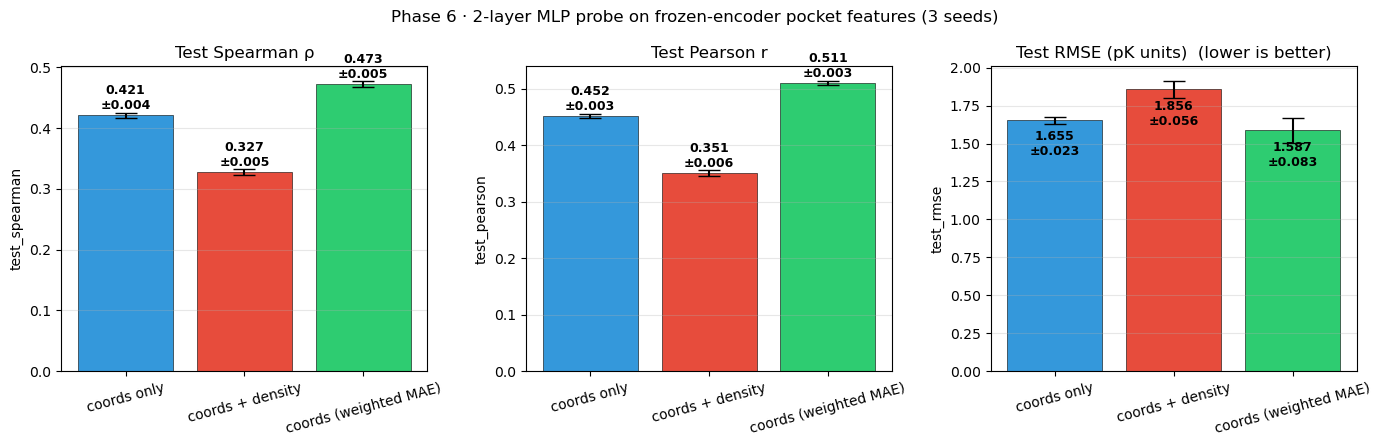

In [3]:
metrics = [
    ("test_spearman", "Test Spearman ρ",  False),
    ("test_pearson",  "Test Pearson r",    False),
    ("test_rmse",     "Test RMSE (pK units)", True),  # lower is better
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (col, title, lower_better) in zip(axes, metrics):
    sub = res.groupby("condition")[col].agg(["mean", "std"]).reindex(CONDITIONS)
    xs = [LABEL[c] for c in CONDITIONS]
    cs = [COLOR[c] for c in CONDITIONS]
    bars = ax.bar(xs, sub["mean"], yerr=sub["std"], capsize=8, color=cs,
                  edgecolor="black", linewidth=0.4)
    offset = sub["std"].max() * 0.8 + 1e-3
    for i, (m, s) in enumerate(zip(sub["mean"], sub["std"])):
        ax.text(i, m + (-offset if lower_better else offset),
                f"{m:.3f}\n±{s:.3f}",
                ha="center", va="top" if lower_better else "bottom",
                fontsize=9, fontweight="bold")
    ax.set_title(title + ("  (lower is better)" if lower_better else ""))
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelrotation=15)
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Phase 6 · 2-layer MLP probe on frozen-encoder pocket features (3 seeds)")
fig.tight_layout()
plt.show()

## 3. Per-seed test ρ — stability check

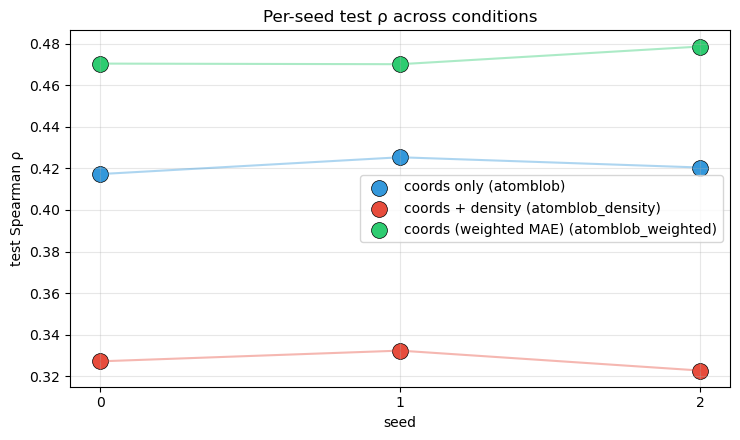

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for cond in CONDITIONS:
    sub = res[res['condition'] == cond]
    ax.scatter(sub['seed'], sub['test_spearman'],
               s=130, color=COLOR[cond], edgecolor='black', linewidth=0.5,
               label=f"{LABEL[cond]} ({cond})")
    ax.plot(sub['seed'], sub['test_spearman'], color=COLOR[cond], alpha=0.4)

ax.set_xlabel('seed')
ax.set_ylabel('test Spearman ρ')
ax.set_title('Per-seed test ρ across conditions')
ax.legend(loc='center right')
ax.grid(alpha=0.3)
ax.set_xticks(sorted(res['seed'].unique()))
fig.tight_layout()
plt.show()

## 4. Predicted vs actual pK

Re-trains seed=0 of each condition inline, then plots predictions on the test set. Same split + MLP architecture as the saved results.

In [5]:
# ─── Re-train helpers (mirrors 01c_pdbbind_probe.py) ──────────────────────────

class MLP2(nn.Module):
    def __init__(self, input_dim, hidden=128, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)


def load_lp_index(csv_path):
    df = pd.read_csv(csv_path).rename(columns={"Unnamed: 0": "pdb_id", "value": "pK"})
    df["pdb_id"] = df["pdb_id"].str.lower()
    return df


def build_dataset(features, lp_df, drop_covalent=True):
    df = lp_df.copy()
    if drop_covalent: df = df[~df["covalent"].astype(bool)]
    df = df[df["pdb_id"].isin(features.keys())]
    df = df[df["new_split"].isin(["train", "val", "test"])]
    df = df.dropna(subset=["pK"])
    out = {}
    for split in ("train", "val", "test"):
        sub  = df[df["new_split"] == split]
        pids = sub["pdb_id"].tolist()
        X    = np.stack([features[p].numpy() for p in pids]).astype(np.float32)
        y    = sub["pK"].astype(np.float32).to_numpy()
        out[split] = {"X": X, "y": y, "pid": pids}
    return out


def train_and_predict(data, seed=0, max_epochs=200, patience=30,
                      lr=1e-3, weight_decay=1e-4, batch_size=64, device=DEVICE):
    torch.manual_seed(seed); np.random.seed(seed)
    Xtr, ytr = torch.from_numpy(data["train"]["X"]).to(device), torch.from_numpy(data["train"]["y"]).to(device)
    Xva, yva = torch.from_numpy(data["val"  ]["X"]).to(device), torch.from_numpy(data["val"  ]["y"]).to(device)
    Xte      = torch.from_numpy(data["test" ]["X"]).to(device)

    model = MLP2(Xtr.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val, best_state, since = -np.inf, None, 0
    for epoch in range(max_epochs):
        model.train()
        perm = torch.randperm(Xtr.size(0), device=device)
        for s in range(0, Xtr.size(0), batch_size):
            idx = perm[s:s+batch_size]
            opt.zero_grad()
            loss = nn.functional.mse_loss(model(Xtr[idx]), ytr[idx])
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val_pred = model(Xva).cpu().numpy()
        val_rho = spearmanr(val_pred, yva.cpu().numpy()).statistic
        if val_rho > best_val:
            best_val, best_state, since = val_rho, {k: v.detach().clone() for k, v in model.state_dict().items()}, 0
        else:
            since += 1
            if since >= patience: break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        return model(Xte).cpu().numpy()


# ─── Load features, intersect, train, collect predictions ─────────────────────

lp_df = load_lp_index(INDEX_CSV)
all_feats = {c: torch.load(FEAT_DIR / f"{c}_e99.pt", weights_only=False)["features"]
             for c in CONDITIONS}
shared = set.intersection(*(set(f.keys()) for f in all_feats.values()))
print(f"shared pids: {len(shared):,}")

preds = {}
y_true = None
test_pids = None
for cond in CONDITIONS:
    feats = {p: v for p, v in all_feats[cond].items() if p in shared}
    data  = build_dataset(feats, lp_df)
    preds[cond] = train_and_predict(data, seed=0)
    if y_true is None:
        y_true   = data["test"]["y"]
        test_pids = data["test"]["pid"]
    print(f"  {cond:24s}  test ρ={spearmanr(preds[cond], y_true).statistic:.4f}  "
          f"r={pearsonr(preds[cond], y_true).statistic:.4f}")

shared pids: 4,827
  atomblob                  test ρ=0.4173  r=0.4485
  atomblob_density          test ρ=0.3272  r=0.3512
  atomblob_weighted         test ρ=0.4704  r=0.5086


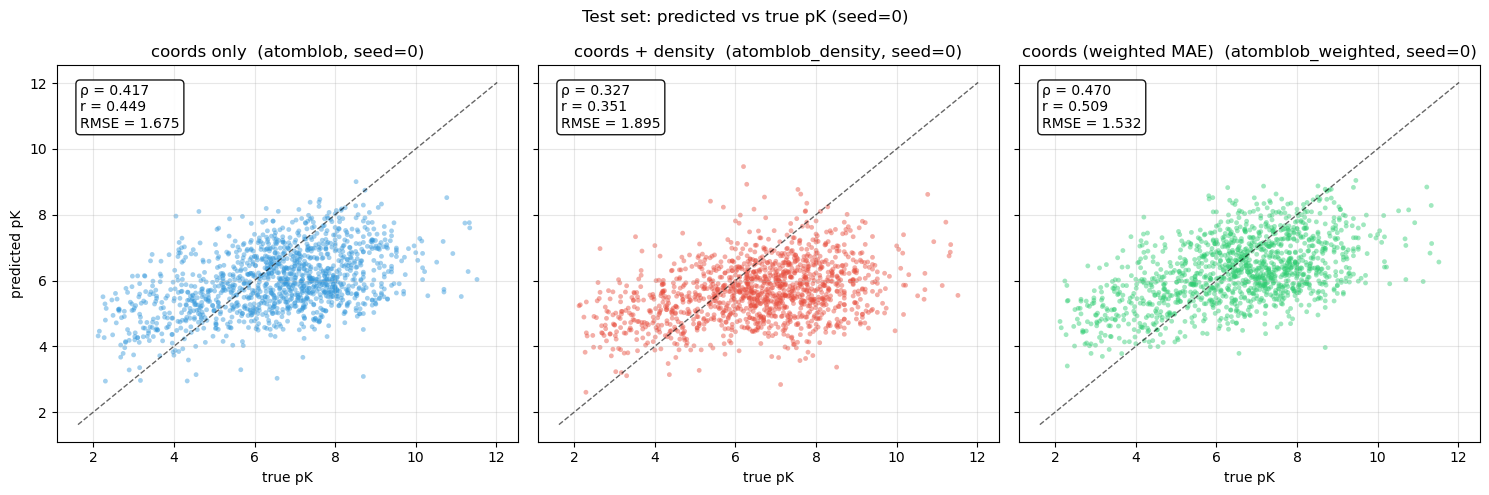

In [6]:
n = len(CONDITIONS)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharex=True, sharey=True)
lo = min(y_true.min(), *(p.min() for p in preds.values())) - 0.5
hi = max(y_true.max(), *(p.max() for p in preds.values())) + 0.5
for ax, cond in zip(axes, CONDITIONS):
    p = preds[cond]
    ax.scatter(y_true, p, s=12, color=COLOR[cond], alpha=0.45, edgecolor="none")
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, alpha=0.6, label="y = x")
    rho  = spearmanr(p, y_true).statistic
    r    = pearsonr (p, y_true).statistic
    rmse = np.sqrt(((p - y_true) ** 2).mean())
    ax.text(0.05, 0.95,
            f"ρ = {rho:.3f}\nr = {r:.3f}\nRMSE = {rmse:.3f}",
            transform=ax.transAxes, va="top", ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.9), fontsize=10)
    ax.set_xlabel("true pK")
    ax.set_title(f"{LABEL[cond]}  ({cond}, seed=0)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("predicted pK")
fig.suptitle("Test set: predicted vs true pK (seed=0)")
fig.tight_layout()
plt.show()

## 5. Residual distribution

Per-sample residual (predicted − true) on the test set. Tighter = better calibration.

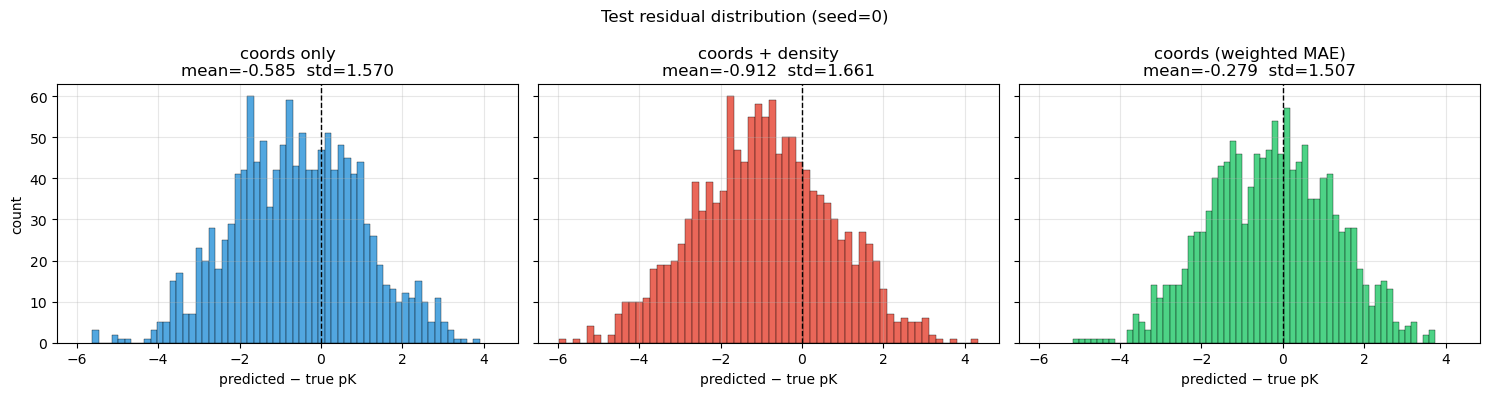

In [7]:
n = len(CONDITIONS)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharex=True, sharey=True)
for ax, cond in zip(axes, CONDITIONS):
    resid = preds[cond] - y_true
    ax.hist(resid, bins=60, color=COLOR[cond], edgecolor="black", linewidth=0.3, alpha=0.85)
    ax.axvline(0, color="k", linestyle="--", linewidth=1)
    ax.set_title(f"{LABEL[cond]}\nmean={resid.mean():+.3f}  std={resid.std():.3f}")
    ax.set_xlabel("predicted − true pK")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("count")
fig.suptitle("Test residual distribution (seed=0)")
fig.tight_layout()
plt.show()

## 6. Per-complex Δ|error| vs the vanilla `atomblob` baseline

For each test complex, plot how much closer (or farther) the alternative is to the true pK than vanilla `atomblob`. **Negative** mean ⇒ the alternative is on-average closer to truth than coords-only.

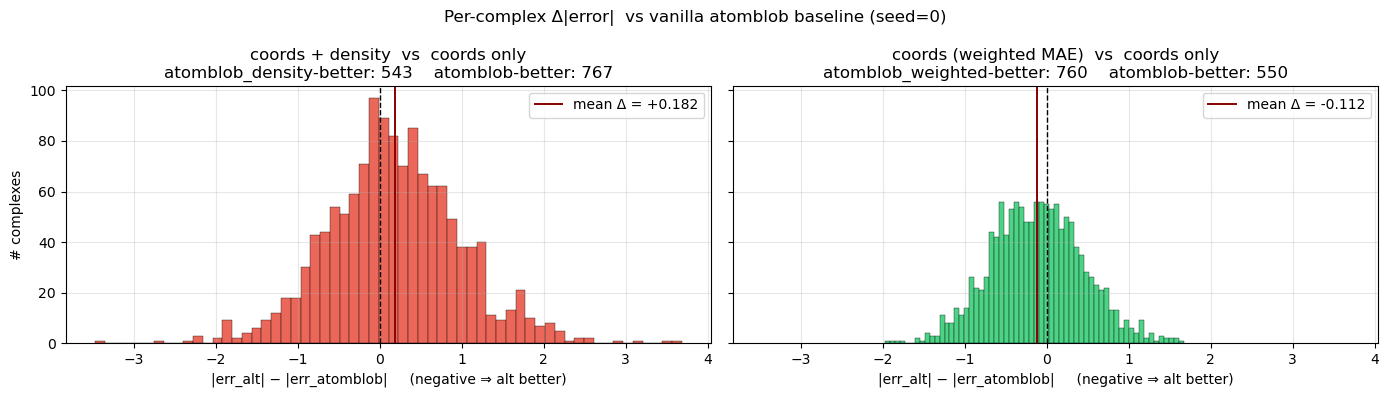

In [8]:
err = {c: np.abs(preds[c] - y_true) for c in CONDITIONS}
alts = [c for c in CONDITIONS if c != "atomblob"]

fig, axes = plt.subplots(1, len(alts), figsize=(7 * len(alts), 4), sharex=True, sharey=True)
if len(alts) == 1:
    axes = [axes]
for ax, alt in zip(axes, alts):
    delta = err[alt] - err["atomblob"]
    n_alt_better      = int((delta < 0).sum())
    n_atomblob_better = int((delta > 0).sum())
    ax.hist(delta, bins=60, color=COLOR[alt], edgecolor="black", linewidth=0.3, alpha=0.85)
    ax.axvline(0, color="k", linestyle="--", linewidth=1)
    ax.axvline(delta.mean(), color="darkred", linestyle="-", linewidth=1.4,
               label=f"mean Δ = {delta.mean():+.3f}")
    ax.set_xlabel("|err_alt| − |err_atomblob|     (negative ⇒ alt better)")
    ax.set_title(
        f"{LABEL[alt]}  vs  coords only\n"
        f"{alt}-better: {n_alt_better:,}    atomblob-better: {n_atomblob_better:,}"
    )
    ax.legend()
    ax.grid(alpha=0.3)
axes[0].set_ylabel("# complexes")
fig.suptitle("Per-complex Δ|error|  vs vanilla atomblob baseline (seed=0)")
fig.tight_layout()
plt.show()